# 2. Feature Engineering & Exploration

Risk Factors: https://www.cdc.gov/heart-disease/risk-factors/index.html   

Several health conditions, your lifestyle, and your age and family history can increase your risk for heart disease. These are called risk factors. Key risk factors for heart disease include:

- High blood pressure
- High cholesterol
- Smoking

Some risk factors for heart disease cannot be controlled, such as your age or family history. But you can take steps to lower your risk by changing the factors you can control.
In addition

- Polynomial features (e.g., age², bmi²) --> To weigh these heavier
- Pulse Pressure = systolic_bp−diastolic_bp
- bmi * cholesterol: could capture the compounded risk of high weight and high lipids --> High BMI (overweight/obesity) is strongly associated with adverse lipid profiles, specifically increasing LDL ("bad") cholesterol and decreasing HDL ("good") cholesterol


If you use a linear model, these highly correlated features can cause instability. You might consider:
Mean Arterial Pressure (MAP): A weighted average of your two BP readings:
Mean Arterial Pressure: $MAP=diastolic + \frac{1}{3} (systolic- diastolic)$

In [1]:
# Load Data
import pandas as pd

df = pd.read_csv("data/raw/cardiovascular_risk_dataset.csv")
df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


## 2.1 Data Cleaning

Before exploring which additional features could be created to consider the risk factors, we clean our original dataframe, based on what we found out in the EDA. As we did not find any missing values or duplicates, we will only drop columns. We will drop Patient_ID, as it is a unique identifier without any predictive value, and we will drop heart_disease_risk_score, as it directly encodes with our target (risk_category), which would cause leakage. 

In [2]:
# Drop Patient_ID and heart_disease_risk_score in a new dataframe so we do not change our original one 
df_clean = df.copy()

df_clean = df_clean.drop(columns=['Patient_ID', 'heart_disease_risk_score'])

print("Cleaned dataframe shape:", df_clean.shape)
print("Columns: ", df_clean.columns.tolist())

Cleaned dataframe shape: (5500, 15)
Columns:  ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'smoking_status', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'family_history_heart_disease', 'diet_quality_score', 'alcohol_units_per_week', 'risk_category']


## 2.2 Train-Test Split
We perform the train–test split before feature engineering because any decision about creating, selecting, or removing features must be based solely on the training data; otherwise, information from the test set would indirectly influence the model, leading to data leakage and overly optimistic performance estimates.

In [3]:
from sklearn.model_selection import train_test_split

# Separating features from target variable
X = df_clean.drop(columns=['risk_category'])
y = df_clean['risk_category']

# Split into training and tetsing set 80/20 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y , shuffle = True) # check if we should really stratify -> justify it in text 

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nClass distribution in training set:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in test set:\n", y_test.value_counts(normalize=True))

KeyboardInterrupt: 

## 2.3 Feature Creation

As mentioned above, there are certain risk factors for getting a heart disease. While our dataset already provides some of these factors, by creating new features from the existing ones, we aim to better capture relationships that raw columns cannot express directly. We organise our engineered features into three categories: 
polynomial transformations, interaction features, and binned flag features.

All features are created and validated on X_train data only to prevent leakage from the test set.

In [4]:
# using a copy of X_train dataframe to later being able to distinguish from original features and created ones 
df_engineered = X_train.copy()
df_engineered.head()

NameError: name 'X_train' is not defined

### 2.3.1 Polynominal Transformations 
By squaring a variable, we allow the model to reflect the accelerating nature of certain risk factors. For example, cardiovascular risk does not increase at a constant rate with age or BMI, but accelerates as values grow larger. 

In [ ]:
# Transform variables
df_engineered['age_squared'] = df_engineered['age'] ** 2
df_engineered['bmi_squared'] = df_engineered['bmi'] ** 2 

### 2.3.2 Interaction Features
These features show how two variables together can create a stronger risk signal than each variable on its own. Interaction terms are especially helpful for logistic regression, since it cannot capture these combined effects automatically. We also combine systolic and diastolic blood pressure into summary measures like Pulse Pressure and Mean Arterial Pressure (MAP).

- Pulse Presssure: reflects the difference between systolic and diastolic blood pressure and can indicate how stiff or elastic the arteries are. Higher values are often associated with increased cardiovascular risk, making it a useful indicator of heart and vascular health.
- Mean Arterial Pressure (MAP): Mean Arterial Pressure (MAP) shows the average pressure in the arteries over one heartbeat. It is important because it reflects how much overall pressure the heart has to work against to pump blood through the body.
- BMI x Age: reflects that the cardiovascular risk linked to excess weight can increase as people get older, meaning that high BMI may have a stronger impact at higher ages.
- BMI x Cholesterol: captures that the health risk of high body weight may become stronger when cholesterol levels are also elevated, since both factors together can increase cardiovascular risk more than each one alone.
- Cholesterol/Age: this ratio helps to show how high someone’s cholesterol level is relative to their age, since elevated cholesterol at a younger age may indicate a higher long-term cardiovascular risk.

In [ ]:
# Add interactions
df_engineered['pulse_pressure'] = df_engineered['systolic_bp'] - df_engineered['diastolic_bp']
df_engineered['map'] = df_engineered['diastolic_bp'] + (df_engineered['systolic_bp'] - df_engineered['diastolic_bp']) / 3
df_engineered['bmi_x_age'] = df_engineered['bmi'] * df_engineered['age']
df_engineered['bmi_x_cholesterol'] = df_engineered['bmi'] * df_engineered['cholesterol_mg_dl']
df_engineered['cholesterol_age_ratio'] = df_engineered['cholesterol_mg_dl'] / df_engineered['age']

### 2.3.3 Binned Flag Features
These features convert clinically established thresholds into binary indicators. We explicitly include boundaries supported by medical guidelines to help the model detecting meaninful thresholds more easily. This is particularly useful for tree-based models, as it provides clear and interpretable split points. The thresholds are based on WHO and established cardiology guidelines.

-> add link with WHO thresholds!! 

- Hypertension Flag: identifies individuals who meet the clinical definition of high blood pressure (systolic ≥ 140 or diastolic ≥ 90) and is important because hypertension is a major risk factor for cardiovascular disease.
- Obesity Flag: identifies individuals with a BMI ≥ 30, based on the WHO definition of obesity, and is important because obesity is strongly associated with increased cardiovascular and metabolic risk.
- High Cholesterol Flag: identifies individuals with cholesterol levels ≥ 240 mg/dl, a clinically recognized high-risk threshold, and is important because elevated cholesterol significantly increases the risk of cardiovascular disease.
- Inactivity Flag: identifies individuals taking fewer than 5,000 steps per day, a commonly used threshold for inactive behavior, and is important because low physical activity is associated with higher cardiovascular risk; our distribution analysis also showed a noticeable concentration of patients below this level (see EDA).
- Sleep Deviation: captures how much a person’s sleep duration differs from the recommended 7 hours, and is important because both too little and too much sleep have been linked to increased cardiovascular risk.
- Alcohol Deviation: measures how much a person’s weekly alcohol consumption differs from the WHO recommendation of 14 units, where negative values indicate consumption within the recommended limit and positive values reflect the amount of excess intake, which is associated with increased health risk.

In [ ]:
# Add Binary/ binned features 
df_engineered['hypertension_flag'] = ((df_engineered['systolic_bp'] >= 140) | (df_engineered['diastolic_bp'] >= 90)).astype(int)
df_engineered['obesity_flag'] = (df_engineered['bmi'] >= 30).astype(int)
df_engineered['high_cholesterol_flag'] = (df_engineered['cholesterol_mg_dl'] >= 240).astype(int)
df_engineered['inactivity_flag'] = (df_engineered['daily_steps'] < 5000).astype(int)
df_engineered['sleep_deviation'] = (df_engineered['sleep_hours'] - 7).abs()
df_engineered['alcohol_deviation'] = df_engineered['alcohol_units_per_week'] - 14

We have engineered ... features that could potentially help our model to predict the risk category better, but also enhances interpretability for medical personel when using our final product. We will in the next step have to verify, which features will have an importance for modelling. 

In [3]:
def feature_engineering(df):
    # Transform variables
    df['age_squared'] = df['age'] ** 2
    df['bmi_squared'] = df['bmi'] ** 2 

    # Add interactions
    df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
    df['map'] = df['diastolic_bp'] + (df['systolic_bp'] - df['diastolic_bp']) / 3
    df['bmi_x_age'] = df['bmi'] * df['age']
    df['bmi_x_cholesterol'] = df['bmi'] * df['cholesterol_mg_dl']
    df['cholesterol_age_ratio'] = df['cholesterol_mg_dl'] / df['age']

    # Add Binary/ binned features 
    df['hypertension_flag'] = ((df['systolic_bp'] >= 140) | (df['diastolic_bp'] >= 90)).astype(int)
    df['obesity_flag'] = (df['bmi'] >= 30).astype(int)
    df['high_cholesterol_flag'] = (df['cholesterol_mg_dl'] >= 240).astype(int)
    df['inactivity_flag'] = (df['daily_steps'] < 5000).astype(int)
    df['sleep_deviation'] = (df['sleep_hours'] - 7).abs()
    df['alcohol_deviation'] = df['alcohol_units_per_week'] - 14
    df['family_history_heart_disease'] = df['family_history_heart_disease'].map({'Yes': 1, 'No': 0})
    
    return df

In [ ]:
def dataoverview(df_engineered, message = "Data Overview"):
    print(f"{message}\n")
    print("\nNumber of rows: ", df_engineered.shape[0])
    print("Number of columns: ", df_engineered.shape[1])
    print("\nColumns: ", df_engineered.columns.tolist())
    print("\nData Types: \n", df_engineered.dtypes)

dataoverview(df_engineered)

Data Overview


Number of rows:  4400
Number of columns:  27

Columns:  ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'smoking_status', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'family_history_heart_disease', 'diet_quality_score', 'alcohol_units_per_week', 'age_squared', 'bmi_squared', 'pulse_pressure', 'map', 'bmi_x_age', 'bmi_x_cholesterol', 'cholesterol_age_ratio', 'hypertension_flag', 'obesity_flag', 'high_cholesterol_flag', 'inactivity_flag', 'sleep_deviation', 'alcohol_deviation']

Data Types: 
 age                                   int64
bmi                                 float64
systolic_bp                           int64
diastolic_bp                          int64
cholesterol_mg_dl                     int64
resting_heart_rate                    int64
smoking_status                       object
daily_steps                           int64
stress_level                          int64
physical_acti

## 2.4 Feature Validation
 As we engineerd many features that also show redundancy and might make sense in a medical context but not for our prediction model, we will have to validate, which features to include and which ones not. To validate the features we use mutual information, which shows which features most likely will have an impact on our target value. Lastly, we will again create a correlation matrix to identify which features will introduce redundancy and could therefore duplicate effetcs in our model. 

### 2.4.1 Mutual Information Score 
(https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html)

We use the Mutual Information score to measure how strongly each feature is related to the target variable, since it can capture both linear and non-linear relationships and helps us identify which features may be most informative for prediction. 
As this scikit built-in only works with numerical features, which is why we only for the purpose of getting the mutual information score, we temporarily convert the categorical columns 'smoking_status' and 'family_history_heart_disease' into numerical values. 

- family_history_heart_disease is binary (yes/no) → simple 0/1 mapping
- smoking_status has three categories (Never, Former, Current) → ordinal 
  encoding makes clinical sense here, as Current smokers carry more risk 
  than Former, who carry more than Never

In [ ]:
# Using only the training data from df_engineered and the target values from our training set 
X_val = df_engineered.copy()
y_val = y_train.copy()

# Binary encoding for family history
X_val['family_history_heart_disease'] = X_val['family_history_heart_disease'].map(
    {'Yes': 1, 'No': 0}
)

# Ordinal encoding for smoking status
X_val['smoking_status'] = X_val['smoking_status'].map(
    {'Never': 0, 'Former': 1, 'Current': 2}
)

# Confirm no non-numeric columns remain
print("Remaining non-numeric columns:", 
      X_val.select_dtypes(exclude='number').columns.tolist())
print("Shape:", X_val.shape)

Remaining non-numeric columns: []
Shape: (4400, 27)


In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Compute mutual information scores
mi_scores = mutual_info_classif(X_val, y_val, random_state=42)

# Store in a Series for easy sorting and plotting
mi_series = pd.Series(mi_scores, index=X_val.columns)
mi_series = mi_series.sort_values(ascending=False)

print("Mutual Information Scores (sorted):")
print(mi_series)

Mutual Information Scores (sorted):
systolic_bp                         0.577024
map                                 0.508653
cholesterol_mg_dl                   0.478867
bmi_x_age                           0.462523
bmi_x_cholesterol                   0.416737
diastolic_bp                        0.415732
bmi_squared                         0.283115
high_cholesterol_flag               0.281675
bmi                                 0.270321
age                                 0.257688
age_squared                         0.251893
pulse_pressure                      0.249266
hypertension_flag                   0.215414
cholesterol_age_ratio               0.209140
obesity_flag                        0.144101
diet_quality_score                  0.135582
daily_steps                         0.121789
physical_activity_hours_per_week    0.114739
smoking_status                      0.087430
resting_heart_rate                  0.078257
inactivity_flag                     0.077866
alcohol_deviation  

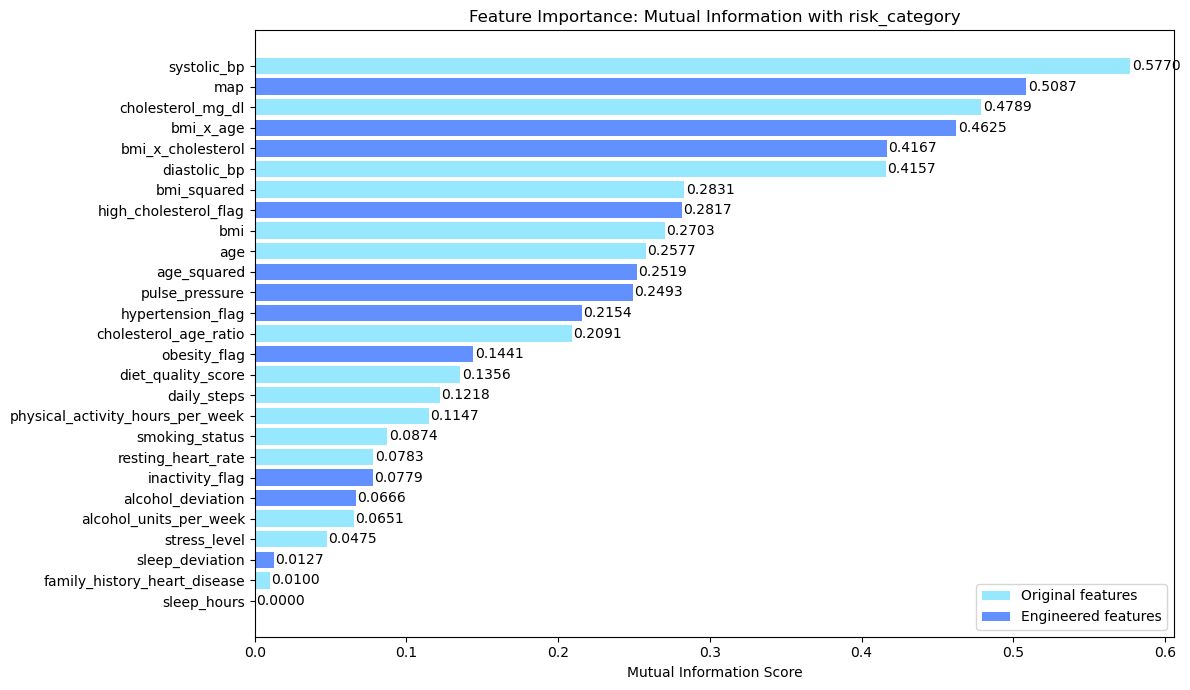

In [ ]:
import matplotlib.pyplot as plt

# Visualise as a ranked bar chart
fig, ax = plt.subplots(figsize=(12, 7))

colors = [ "#6291ff" if col in [
    'age_squared', 'bmi_squered', 'pulse_pressure', 'map', 'bmi_x_age', 'bmi_x_cholesterol', 'cholosterol_age_ratio', 
    'hypertension_flag', 'obesity_flag', 'high_cholesterol_flag', 'inactivity_flag', 'sleep_deviation', 'alcohol_deviation'
] else "#97e8ff" for col in mi_series.index]

bars = ax.barh(mi_series.index, mi_series.values, color=colors)

# Labels and formatting
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Importance: Mutual Information with risk_category')
ax.invert_yaxis()  # highest score at top

# Add value labels on bars
for bar, score in zip(bars, mi_series.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center')

# Add legend to distinguish original vs engineered features
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#97e8ff', label='Original features'),
                   Patch(facecolor='#6291ff', label='Engineered features')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

**Findings:**

Since mutual information has no absolute interpretation, we use it as a relative ranking measure to compare the predictive relevance of features and identify potentially weak variables: 
- '> 0.4: very strong 
- '> 0.3: strong 
- '> 0.1: considerable 
- < 0.05: very weak 

Therefore, we will keep only keep following of our previously engineered features: 
- MAP
- BMI x Age 
- BMI x Cholesterol 
- BMI²
- High Cholosterol Flag 
- Age²
- Pulse Pressure 
- Hypertension Flag 
- Cholesterol-Age Ratio 
- Obesity Flag

Although the Inactivity Flag as well as the Alcohol and Sleep Deviation variables may be clinically meaningful, we exclude them from our final models due to their limited predictive contribution in our analysis.

### 2.4.2 Correlation
After identifying the most informative features, we now check for multicollinearity. Especially for logistic regression, highly correlated variables can inflate coefficient variance and reduce model stability. Therefore, we should drop one of the corrlated features if the correlation is above 0.85. We visualise this using a heatmap, focusing on the variables selected through our mutual information analysis.

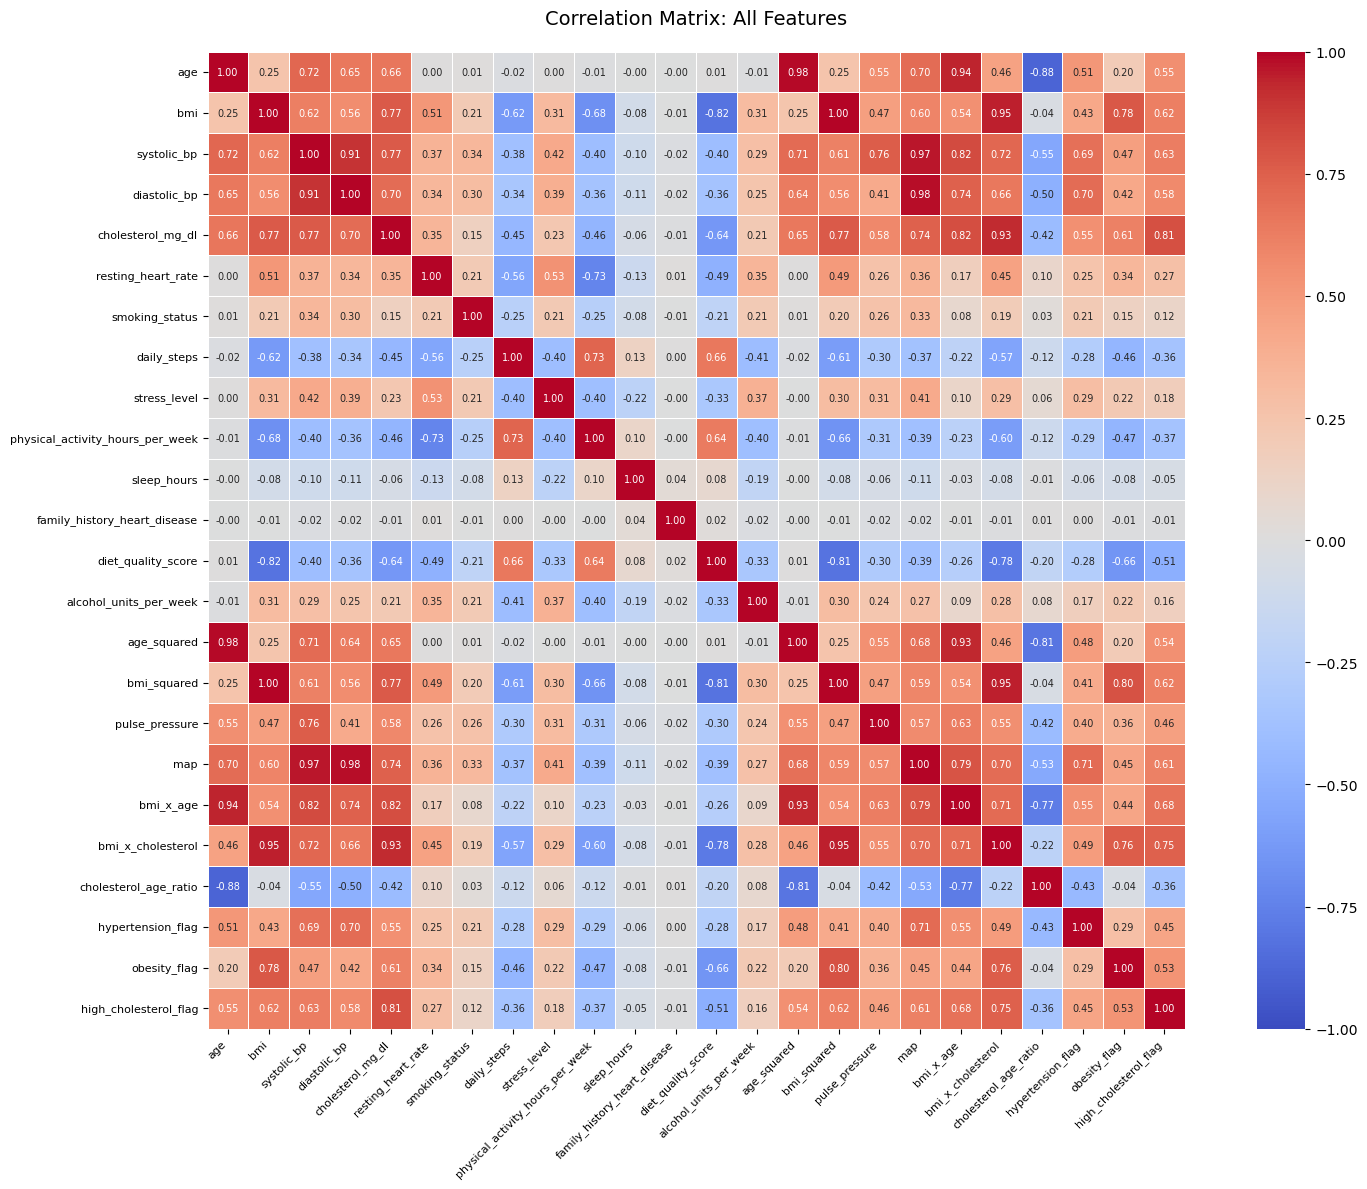


Highly correlated feature pairs (|correlation| > 0.85):
  age — age_squared: 0.98
  age — bmi_x_age: 0.94
  age — cholesterol_age_ratio: -0.88
  bmi — bmi_squared: 1.00
  bmi — bmi_x_cholesterol: 0.95
  systolic_bp — diastolic_bp: 0.91
  systolic_bp — map: 0.97
  diastolic_bp — map: 0.98
  cholesterol_mg_dl — bmi_x_cholesterol: 0.93
  age_squared — bmi_x_age: 0.93
  bmi_squared — bmi_x_cholesterol: 0.95


In [ ]:
import seaborn as sns
import numpy as np

# Dropping engineered features with MI < 0.1
X_val = X_val.drop(columns=['inactivity_flag', 'alcohol_deviation', 'sleep_deviation'])

# Compute correlation matrix on all remaining features 
corr_matrix = X_val.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, annot_kws={"size": 7}, ax=ax)

ax.set_title('Correlation Matrix: All Features', 
             fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Printing any pairs with correlation above 0.85 for easy reference
print("\nHighly correlated feature pairs (|correlation| > 0.85):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            print(f"  {corr_matrix.columns[i]} — {corr_matrix.columns[j]}: "
                  f"{corr_matrix.iloc[i, j]:.2f}")
        


## 2.5 Feature Selection
In this final step before modeling, we create functions with the features that we want to include for our Logistic regression model, as well as a seperate function for features that will be used in our tree models. Our goal is to use specific features depending on the models strengths to optimize our prediction. 

Final logistic regression engineered features:

- pulse_pressure — replaces systolic_bp, diastolic_bp, and MAP
- bmi_x_age — captures compounding weight risk over time
- bmi_x_cholesterol — captures compounded metabolic risk

Tree model engineered features:

- hypertension_flag — clinical BP threshold
- high_cholesterol_flag — clinical cholesterol threshold
- obesity_flag — WHO BMI threshold

-> Justification missing 

In [5]:
def feature_engineering_lr(X_log_features):
    """
    Feature engineering for Logistic Regression.
    Replaces systolic_bp and diastolic_bp with pulse_pressure,
    drops redundant features identified via correlation analysis.
    """
    X_log_features = X_train.copy()
    
    # Engineered features
    X_log_features['pulse_pressure'] = X_log_features['systolic_bp'] - X_log_features['diastolic_bp']
    X_log_features['bmi_x_age'] = X_log_features['bmi'] * X_log_features['age']
    X_log_features['bmi_x_cholesterol'] = X_log_features['bmi'] * X_log_features['cholesterol_mg_dl']
    
    # Drop originals replaced by pulse_pressure
    # Drop redundant features confirmed by correlation matrix
    X_log_features = X_log_features.drop(columns=[
        'systolic_bp', 'diastolic_bp', 'age', 'bmi', 'sleep_hours'
    ], errors='ignore')
    
    return X

In [ ]:
def feature_engineering_trees(X_tree_features):
    """
    Feature engineering for Random Forest and Gradient Boosting.
    Keeps original columns alongside engineered features since
    tree models handle multicollinearity natively.
    """
    X_tree_features = X_train.copy()
    
    # Engineered features
    X_tree_features['high_cholesterol_flag'] = (X_tree_features['cholesterol_mg_dl'] >= 240).astype(int)
    X_tree_features['hypertension_flag'] = ((X_tree_features['systolic_bp'] >= 140) | (X_tree_features['diastolic_bp'] >= 90)).astype(int)
    X_tree_features['obese_flag'] = (X_tree_features['bmi'] >= 30).astype(int)
    
    # Only drop features with no mutual information signal
    X_tree_features = X_tree_features.drop(columns=['sleep_hours'], errors='ignore')
    
    return X_tree_features

# 2.5 Feature Selection with LassoCV

# ?. XGBoost - Fit Model

In [4]:
from sklearn.model_selection import train_test_split

df_boost = feature_engineering(df_clean.copy())

# Define X/y
TARGET = "risk_category"
X = df_boost.drop(columns=[TARGET])
y = df_boost[TARGET]

# Split into training and testing set 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Encode target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # High=0, Low=1, Medium=2
y_test_encoded = le.transform(y_test)

# Check the mapping
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    print(f"{cls} → {idx}")


High → 0
Low → 1
Medium → 2


## ?.1 Preprocessing

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numerical_cols = [
    'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl',
    'resting_heart_rate', 'daily_steps', 'stress_level',
    'physical_activity_hours_per_week', 'sleep_hours',
    'diet_quality_score', 'alcohol_units_per_week', 'age_squared',
    'bmi_squared', 'pulse_pressure', 'map', 'bmi_x_age', 'bmi_x_cholesterol',
    'cholesterol_age_ratio', 'hypertension_flag', 'obesity_flag',
    'high_cholesterol_flag', 'inactivity_flag', 'sleep_deviation',
    'alcohol_deviation', 'family_history_heart_disease'
]

categorical_cols = [
    'smoking_status' 
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [7]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## ?.2 Feature Selection

In [8]:
from sklearn.linear_model import LogisticRegressionCV

feature_names = (
    numerical_cols +
    list(preprocessor.named_transformers_['cat']
         .named_steps['encoder']
         .get_feature_names_out(categorical_cols))
)

logit_cv = LogisticRegressionCV(
    cv=5,
    penalty='l1',
    solver='saga',
    multi_class='multinomial',
    random_state=42,
    max_iter=10000
)
logit_cv.fit(X_train_processed, y_train_encoded)

# For multiclass, coef_ has shape (n_classes, n_features)
# Take the mean absolute coefficient across all classes
import numpy as np
coef_mean = np.mean(np.abs(logit_cv.coef_), axis=0)
coef_series = pd.Series(coef_mean, index=feature_names)
selected_features = coef_series[coef_series > 0].sort_values(ascending=False)

print(f"Features selected: {len(selected_features)}")
print(selected_features)

# Total features after engineering and encoding
total_features = X_train_processed.shape[1]
print(f"Total features after engineering and encoding: {total_features}")

/Users/max/Desktop/Machine_Learning_HeartDiseaseDetection/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Features selected: 27
smoking_status_Current              4.540688
bmi_x_age                           3.194258
smoking_status_Never                2.221280
systolic_bp                         2.124725
age                                 1.931327
family_history_heart_disease        1.861950
physical_activity_hours_per_week    1.715259
bmi_x_cholesterol                   1.315992
cholesterol_mg_dl                   1.314692
diet_quality_score                  1.197463
stress_level                        1.066929
age_squared                         0.580855
bmi_squared                         0.356562
obesity_flag                        0.195290
daily_steps                         0.173487
high_cholesterol_flag               0.136313
bmi                                 0.128287
inactivity_flag                     0.119990
cholesterol_age_ratio               0.109642
map                                 0.093139
sleep_hours                         0.089528
sleep_deviation                  

In [11]:
# Select features with mean absolute coefficient above 0.1 (threshold can be adjusted)
selected_features_final = coef_series[coef_series >= 0.1].sort_values(ascending=False)
print(selected_features_final)
print(f"Features selected: {len(selected_features_final)}")

# Get indices for subsetting processed arrays
selected_idx = [list(feature_names).index(f) for f in selected_features_final.index]
X_train_selected = X_train_processed[:, selected_idx]
X_test_selected = X_test_processed[:, selected_idx]

smoking_status_Current              4.540688
bmi_x_age                           3.194258
smoking_status_Never                2.221280
systolic_bp                         2.124725
age                                 1.931327
family_history_heart_disease        1.861950
physical_activity_hours_per_week    1.715259
bmi_x_cholesterol                   1.315992
cholesterol_mg_dl                   1.314692
diet_quality_score                  1.197463
stress_level                        1.066929
age_squared                         0.580855
bmi_squared                         0.356562
obesity_flag                        0.195290
daily_steps                         0.173487
high_cholesterol_flag               0.136313
bmi                                 0.128287
inactivity_flag                     0.119990
cholesterol_age_ratio               0.109642
dtype: float64
Features selected: 19


## ?.3 Fit Baseline Logistic Regression (L1)

In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score

y_pred_baseline = logit_cv.predict(X_test_processed)
y_prob_baseline = logit_cv.predict_proba(X_test_processed)

print("Logistic Regression (L1) Performance")
print("-"*40)
print(f"Accuracy:  {accuracy_score(y_test_encoded, y_pred_baseline):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_encoded, y_prob_baseline, multi_class='ovr'):.4f}")
print(f"F1:        {f1_score(y_test_encoded, y_pred_baseline, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_encoded, y_pred_baseline, average='weighted'):.4f}")



# Compare train vs test performance
y_pred_train = logit_cv.predict(X_train_processed)

print("\nTrain vs Test Accuracy")
print("Train Accuracy:", accuracy_score(y_train_encoded, y_pred_train))
print("Test Accuracy: ", accuracy_score(y_test_encoded, y_pred_baseline))

Logistic Regression (L1) Performance
----------------------------------------
Accuracy:  0.9436
ROC-AUC:   0.9943
F1:        0.9437
Recall:    0.9436

Train vs Test Accuracy
Train Accuracy: 0.9440909090909091
Test Accuracy:  0.9436363636363636


**Note**:
What seemed to be an overfit on training data at first, turned out to be just a very good model, showing consistent performance on the train, as well as the test set. This suggests that our feautures are very strong in predicting the heart disease risk and the categories are clearly distinguishable for the model. 

In [17]:
import xgboost as xgb
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb.fit(X_train_selected, y_train_encoded)

y_pred_xgb = xgb.predict(X_test_selected)
y_prob_xgb = xgb.predict_proba(X_test_selected)

print("XGBoost Performance")
print("-" *40)
print(f"Accuracy:  {accuracy_score(y_test_encoded, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_encoded, y_prob_xgb, multi_class='ovr'):.4f}")
print(f"F1:        {f1_score(y_test_encoded, y_pred_xgb, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_encoded, y_pred_xgb, average='weighted'):.4f}")

/Users/max/Desktop/Machine_Learning_HeartDiseaseDetection/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:36:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Performance
----------------------------------------
Accuracy:  0.9209
ROC-AUC:   0.9911
F1:        0.9211
Recall:    0.9209


# ?.4 XGBoost - Hyperparameter Tuning

In [32]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],          # shallower trees
    'learning_rate': [0.01, 0.05],   # slower learning
    'subsample': [0.5, 0.6, 0.7],    # more aggressive subsampling
    'colsample_bytree': [0.5, 0.6],  # fewer features per tree
    'min_child_weight': [5, 10, 20], # higher = more conservative splits
    'gamma': [0.5, 1, 2, 5],        # higher = more conservative splits
    'reg_alpha': [0.1, 0.5, 1, 5],  # L1 regularization
    'reg_lambda': [1, 2, 5, 10]     # L2 regularization
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_selected, y_train_encoded)
print("Best params:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_, 4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.6}
Best CV accuracy: 0.9189


In [33]:
best_xgb = search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test_selected)
y_prob_tuned = best_xgb.predict_proba(X_test_selected)

print("Tuned XGBoost Performance")
print("-" *40)
print(f"Accuracy:  {accuracy_score(y_test_encoded, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_encoded, y_prob_tuned, multi_class='ovr'):.4f}")
print(f"F1:        {f1_score(y_test_encoded, y_pred_tuned, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_encoded, y_pred_tuned, average='weighted'):.4f}")

# Compare train vs test performance
print("\nTrain vs Test Accuracy for Tuned XGBoost")
y_pred_train_xgb = best_xgb.predict(X_train_selected)
print("Train Accuracy:", accuracy_score(y_train_encoded, y_pred_train_xgb))
print("Test Accuracy: ", accuracy_score(y_test_encoded, y_pred_tuned))

Tuned XGBoost Performance
----------------------------------------
Accuracy:  0.9291
ROC-AUC:   0.9906
F1:        0.9293
Recall:    0.9291

Train vs Test Accuracy for Tuned XGBoost
Train Accuracy: 0.9561363636363637
Test Accuracy:  0.9290909090909091


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.DataFrame({
    'Model': [
        'Logistic Regression (L1)',
        'XGBoost (untuned)',
        'XGBoost (tuned)'
    ],
    'Accuracy':  [0.9436, 0.9209, 0.9291],
    'ROC-AUC':   [0.9943, 0.9911, 0.9906],
    'F1':        [0.9437, 0.9211, 0.9293],
    'Recall':    [0.9436, 0.9209, 0.9291],
})

print(results.to_string(index=False))

                   Model  Accuracy  ROC-AUC     F1  Recall
Logistic Regression (L1)    0.9436   0.9943 0.9437  0.9436
       XGBoost (untuned)    0.9209   0.9911 0.9211  0.9209
         XGBoost (tuned)    0.9291   0.9906 0.9293  0.9291


**Note**:

Baseline: Logistic Regression with L1 penalty
Advanced: XGBoost (gradient boosted trees)

Key Findings:
- Logistic Regression achieved 94.36% accuracy with a near-zero train/test gap (0.04%) indicating perfect generalization.

- XGBoost initially overfit significantly (train/test gap of 6.5%), requiring two rounds of regularization tuning to reduce
  the gap to an acceptable 2.7%.

- Even after tuning, XGBoost (92.91%) could not surpass the baseline (94.36%).

Conclusion:
Logistic regression (L1) is the superior model for this dataset. Heart disease risk features (BMI, cholesterol, blood pressure, and smoking status) have strong linear relationships with the target. This means added complexity from XGBoost does not improve generalization and initially decreases it.

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test_encoded, y_pred_baseline, target_names=le.classes_))

              precision    recall  f1-score   support

        High       0.95      0.95      0.95       288
         Low       0.95      0.95      0.95       348
      Medium       0.93      0.94      0.93       464

    accuracy                           0.94      1100
   macro avg       0.95      0.95      0.95      1100
weighted avg       0.94      0.94      0.94      1100

